In [1]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

np.random.seed(42)
tf.random.set_seed(42)
rng = np.random.default_rng(42)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
Available GPUs: []


=== Image Counts per Split ===
Train - premium: 2400, longberry: 2400, defect: 2400, defect: 2400
Val   - premium: 800, longberry: 800, peaberry: 800, defect: 800
Test  - premium: 800, longberry: 800, peaberry: 800, defect: 800

Train Class Imbalance Ratio (premium / premium): 1.00x

=== Visual Sample Analysis ===
Sample [premium #1]: Size = 256x256px, Color Mode = RGB
Sample [premium #2]: Size = 256x256px, Color Mode = RGB
Sample [premium #3]: Size = 256x256px, Color Mode = RGB
Sample [premium #4]: Size = 256x256px, Color Mode = RGB
Sample [premium #5]: Size = 256x256px, Color Mode = RGB
Sample [longberry #1]: Size = 256x256px, Color Mode = RGB
Sample [longberry #2]: Size = 256x256px, Color Mode = RGB
Sample [longberry #3]: Size = 256x256px, Color Mode = RGB
Sample [longberry #4]: Size = 256x256px, Color Mode = RGB
Sample [longberry #5]: Size = 256x256px, Color Mode = RGB
Sample [peaberry #1]: Size = 256x256px, Color Mode = RGB
Sample [peaberry #2]: Size = 256x256px, Color Mode = RGB


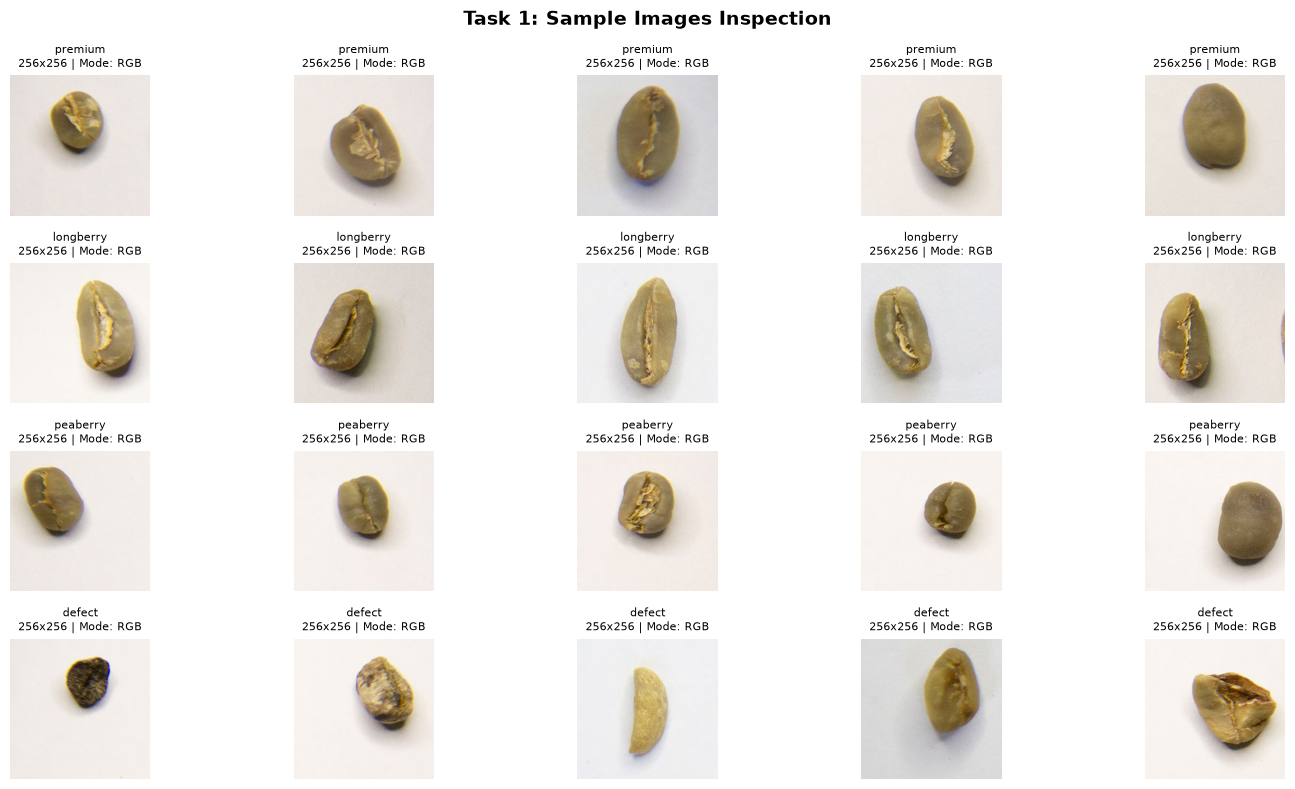

In [2]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\ruthg\Downloads\coffee_dataset"

def display_samples_and_check(base_dir, num_samples=5):
    """
    Samples and displays images per class with dimension and color mode metadata.
    """
    train_dir = os.path.join(base_dir, "train")
    classes = ["premium", "longberry", "peaberry", "defect"]
    
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 8))
    
    print("=== Visual Sample Analysis ===")
    for i, cls in enumerate(classes):
        cls_path = os.path.join(train_dir, cls)
        
        # Support multiple image extensions
        img_paths = (
            glob.glob(os.path.join(cls_path, "*.jpeg")) + 
            glob.glob(os.path.join(cls_path, "*.jpg")) +
            glob.glob(os.path.join(cls_path, "*.png")) +
            glob.glob(os.path.join(cls_path, "*.JPEG")) +
            glob.glob(os.path.join(cls_path, "*.JPG"))
        )[:num_samples]
        
        if not img_paths:
            print(f"Warning: No images found for class '{cls}' in {cls_path}")
            continue

        for j, img_path in enumerate(img_paths):
            with Image.open(img_path) as img:
                width, height = img.size
                mode = img.mode
                
                ax = axes[i, j] if len(classes) > 1 else axes[j]
                ax.imshow(img, cmap='gray' if mode == 'L' else None)
                ax.set_title(f"{cls}\n{width}x{height} | Mode: {mode}", fontsize=8)
                ax.axis('off')
                
                print(f"Sample [{cls} #{j+1}]: Size = {width}x{height}px, Color Mode = {mode}")

    plt.suptitle("Task 1: Sample Images Inspection", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def inspect_dataset(base_dir):
    """
    Counts images across dataset splits, evaluates class imbalance, 
    and triggers visual sample inspection.
    """
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")
    val_dir = os.path.join(base_dir, "val")
    
    classes = ["premium", "longberry", "peaberry", "defect"]
    counts = {}
    
    for split_name, split_path in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
        counts[split_name] = {}
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            imgs = (
                glob.glob(os.path.join(cls_path, "*.jpeg")) +
                glob.glob(os.path.join(cls_path, "*.jpg")) +
                glob.glob(os.path.join(cls_path, "*.png")) +
                glob.glob(os.path.join(cls_path, "*.JPEG")) +
                glob.glob(os.path.join(cls_path, "*.JPG"))
            )
            counts[split_name][cls] = len(imgs)

    print("=== Image Counts per Split ===")
    print(f"Train - premium: {counts['train']['premium']}, longberry: {counts['train']['longberry']}, defect: {counts['train']['peaberry']}, defect: {counts['train']['defect']}")
    print(f"Val   - premium: {counts['val']['premium']}, longberry: {counts['val']['longberry']}, peaberry: {counts['val']['peaberry']}, defect: {counts['val']['defect']}")
    print(f"Test  - premium: {counts['test']['premium']}, longberry: {counts['test']['longberry']}, peaberry: {counts['test']['peaberry']}, defect: {counts['test']['defect']}\n")
    
    # Calculate imbalance ratio relative to largest vs smallest class in training set
    train_counts = counts['train']
    max_cls = max(train_counts, key=train_counts.get)
    min_cls = min(train_counts, key=train_counts.get)
    
    if train_counts[min_cls] > 0:
        imbalance_ratio = train_counts[max_cls] / train_counts[min_cls]
        print(f"Train Class Imbalance Ratio ({max_cls} / {min_cls}): {imbalance_ratio:.2f}x\n")
    else:
        print(f"Warning: Class '{min_cls}' has 0 training images.\n")

    # Display image grid and details
    display_samples_and_check(base_dir, num_samples=5)


if __name__ == "__main__":
    inspect_dataset(DATA_DIR)

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

DATA_DIR = r"C:\Users\ruthg\Downloads\coffee_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def compute_class_weights(train_ds):
    """
    Computes class weights based on the unaugmented training set count.
    0: defect, 1: longberry, 2: peaberry, 3: premium
    """
    # Extract only the target labels without loading image arrays into memory
    labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
    
    total = len(labels)
    n_defect = np.sum(labels == 0)
    n_longberry = np.sum(labels == 1)
    n_peaberry = np.sum(labels == 2)
    n_premium = np.sum(labels == 3)
    
    weight_for_0 = (1 / n_defect) * (total / 4.0)
    weight_for_1 = (1 / n_longberry) * (total / 4.0)
    weight_for_2 = (1 / n_peaberry) * (total / 4.0)
    weight_for_3 = (1 / n_premium) * (total / 4.0)
    
    class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}
    
    print(f"Total Train Samples: {total}")
    print(f"Defect (Class 0): {n_defect} | Computed Weight: {weight_for_0:.2f}")
    print(f"Longberry (Class 1): {n_longberry} | Computed Weight: {weight_for_1:.2f}")
    print(f"Peaberry (Class 2): {n_peaberry} | Computed Weight: {weight_for_2:.2f}")
    print(f"Premium (Class 3): {n_premium} | Computed Weight: {weight_for_3:.2f}")
    
    return class_weight

def get_data_pipelines(data_dir):
    train_path = os.path.join(data_dir, "train")
    val_path = os.path.join(data_dir, "val")
    test_path = os.path.join(data_dir, "test")

    # Use RGB (3 channels) so the model captures bean color, roast shade, and defect stains
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_path,
        image_size=IMG_SIZE,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=True,
        seed=42
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_path,
        image_size=IMG_SIZE,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_path,
        image_size=IMG_SIZE,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=False
    )

    class_weights = compute_class_weights(train_ds)

    rescaling = layers.Rescaling(1.0 / 255.0)

    # Robust data augmentation for coffee beans (rotational invariance, brightness, contrast)
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(factor=0.5),
        layers.RandomZoom(height_factor=(-0.1, 0.1)),
        layers.RandomContrast(factor=0.1),
        layers.RandomBrightness(factor=0.1, value_range=(0.0, 1.0))
    ], name="data_augmentation")

    # Train: Cache raw un-augmented images -> map transformations -> prefetch
    train_ds = (
        train_ds
        .cache()
        .map(
            lambda x, y: (tf.clip_by_value(data_augmentation(rescaling(x), training=True), 0.0, 1.0), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )
    
    # Val & Test: Cache rescaled images directly
    val_ds = (
        val_ds
        .map(lambda x, y: (rescaling(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )
    
    test_ds = (
        test_ds
        .map(lambda x, y: (rescaling(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )

    return train_ds, val_ds, test_ds, class_weights

if __name__ == "__main__":
    train_ds, val_ds, test_ds, class_weights = get_data_pipelines(DATA_DIR)
    
    for images, labels in train_ds.take(1):
        print("\n=== Verification ===")
        print(f"Batch Image Shape: {images.shape}")
        print(f"Batch Labels Shape: {labels.shape}")
        print(f"Pixel Min: {tf.reduce_min(images):.2f}, Pixel Max: {tf.reduce_max(images):.2f}")

Found 4800 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Total Train Samples: 4800
Defect (Class 0): 1200 | Computed Weight: 1.00
Longberry (Class 1): 1200 | Computed Weight: 1.00
Peaberry (Class 2): 1200 | Computed Weight: 1.00
Premium (Class 3): 1200 | Computed Weight: 1.00

=== Verification ===
Batch Image Shape: (32, 224, 224, 3)
Batch Labels Shape: (32,)
Pixel Min: 0.00, Pixel Max: 1.00


In [4]:
from tensorflow.keras import models, layers
import tensorflow as tf

def build_model(input_shape=(224, 224, 3), num_classes=4):
    """
    Builds a Transfer Learning model using pre-trained MobileNetV2 backbone.
    Replaces Flatten with GlobalAveragePooling2D to prevent overfitting.
    """
    # Pre-trained ImageNet Backbone
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False  # Freeze feature extractor initially

    model = models.Sequential([
        layers.Input(shape=input_shape),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

if __name__ == "__main__":
    model, base_model = build_model((224, 224, 3), num_classes=4)
    model.summary()

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)        

In [5]:
from tensorflow.keras import callbacks
import tensorflow as tf

# 1. Setup Callbacks with Learning Rate Reduction to prevent loss spikes
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("=== Phase 1: Training Classification Head (Backbone Frozen) ===")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,  
    callbacks=[early_stop, reduce_lr]
)

print("\n=== Phase 2: Fine-Tuning Top Backbone Layers ===")
# Unfreeze top layers of the backbone for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate for delicate fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,  
    callbacks=[early_stop, reduce_lr]
)

# Combine history for plotting
history = {
    "accuracy": history_phase1.history["accuracy"] + history_phase2.history["accuracy"],
    "val_accuracy": history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"],
    "loss": history_phase1.history["loss"] + history_phase2.history["loss"],
    "val_loss": history_phase1.history["val_loss"] + history_phase2.history["val_loss"]
}

=== Phase 1: Training Classification Head (Backbone Frozen) ===
Epoch 1/12

  1/150 ━━━━━━━━━━━━━━━━━━━━ 32:01 13s/step - accuracy: 0.2188 - loss: 2.2957
  2/150 ━━━━━━━━━━━━━━━━━━━━ 2:51 1s/step - accuracy: 0.3125 - loss: 1.9247  
  3/150 ━━━━━━━━━━━━━━━━━━━━ 1:59 810ms/step - accuracy: 0.2917 - loss: 1.9117
  4/150 ━━━━━━━━━━━━━━━━━━━━ 1:39 681ms/step - accuracy: 0.3438 - loss: 1.7873
  5/150 ━━━━━━━━━━━━━━━━━━━━ 1:28 613ms/step - accuracy: 0.3750 - loss: 1.7280
  6/150 ━━━━━━━━━━━━━━━━━━━━ 1:21 568ms/step - accuracy: 0.3854 - loss: 1.6782
  7/150 ━━━━━━━━━━━━━━━━━━━━ 1:16 534ms/step - accuracy: 0.4062 - loss: 1.7028
  8/150 ━━━━━━━━━━━━━━━━━━━━ 1:12 509ms/step - accuracy: 0.4023 - loss: 1.6553
  9/150 ━━━━━━━━━━━━━━━━━━━━ 1:10 498ms/step - accuracy: 0.4236 - loss: 1.5917
 10/150 ━━━━━━━━━━━━━━━━━━━━ 1:07 485ms/step - accuracy: 0.4187 - loss: 1.5695
 11/150 ━━━━━━━━━━━━━━━━━━━━ 1:07 483ms/step - accuracy: 0.4403 - loss: 1.5338
 12/150 ━━━━━━━━━━━━━━━━━━━━ 1:05 472ms/step - accuracy: 

C:\Users\ruthg\Downloads\Coffee Predictor\Coffee-Classifier\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


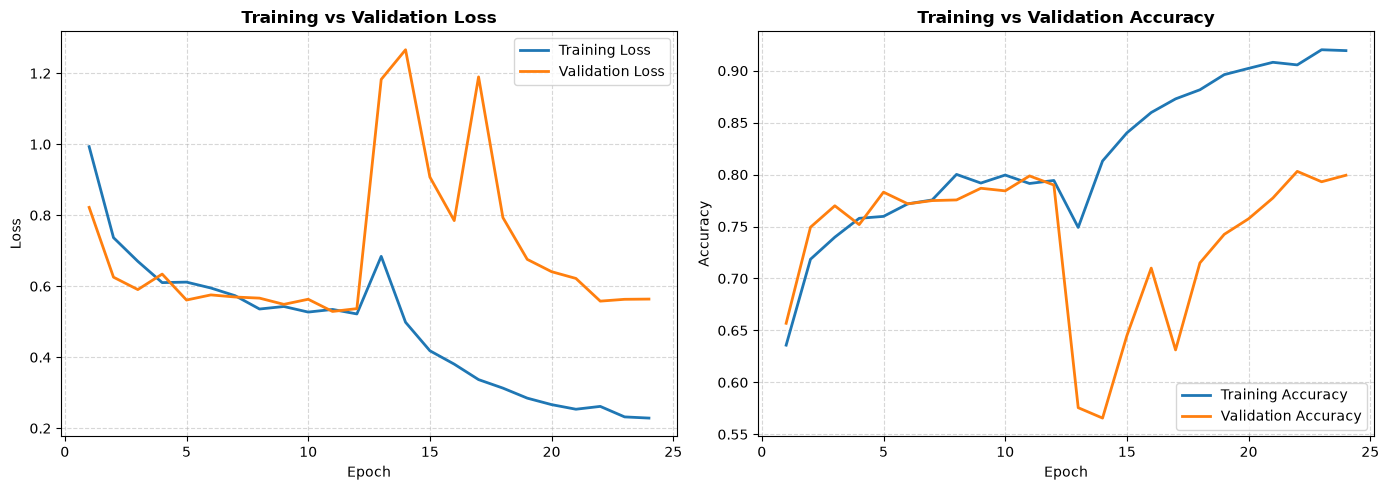

In [6]:
# Extract metric values from combined training history
acc = history["accuracy"] if isinstance(history, dict) else history.history["accuracy"]
val_acc = history["val_accuracy"] if isinstance(history, dict) else history.history["val_accuracy"]
loss = history["loss"] if isinstance(history, dict) else history.history["loss"]
val_loss = history["val_loss"] if isinstance(history, dict) else history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Subplot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label="Training Loss", color="tab:blue", linewidth=2)
plt.plot(epochs_range, val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
plt.title("Training vs Validation Loss", fontweight="bold", fontsize=12)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

# Subplot 2: Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label="Training Accuracy", color="tab:blue", linewidth=2)
plt.plot(epochs_range, val_acc, label="Validation Accuracy", color="tab:orange", linewidth=2)
plt.title("Training vs Validation Accuracy", fontweight="bold", fontsize=12)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


 1/50 ━━━━━━━━━━━━━━━━━━━━ 4:24 5s/step - accuracy: 0.6562 - loss: 1.2977
 2/50 ━━━━━━━━━━━━━━━━━━━━ 1:24 2s/step - accuracy: 0.5000 - loss: 1.7665
 3/50 ━━━━━━━━━━━━━━━━━━━━ 1:07 1s/step - accuracy: 0.5208 - loss: 1.6037
 4/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.4766 - loss: 1.7092 
 5/50 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5063 - loss: 1.6379
 6/50 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5052 - loss: 1.6526
 7/50 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5357 - loss: 1.6029
 8/50 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5508 - loss: 1.5366
 9/50 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5625 - loss: 1.5315
10/50 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5781 - loss: 1.4464
11/50 ━━━━━━━━━━━━━━━━━━━━ 37s 969ms/step - accuracy: 0.5795 - loss: 1.4166
12/50 ━━━━━━━━━━━━━━━━━━━━ 35s 941ms/step - accuracy: 0.5703 - loss: 1.4445
13/50 ━━━━━━━━━━━━━━━━━━━━ 33s 912ms/step - accuracy: 0.5769 - loss: 1.4471
14/50 ━━━━━━━━━━━━━━━━━━━━ 32s 895ms/

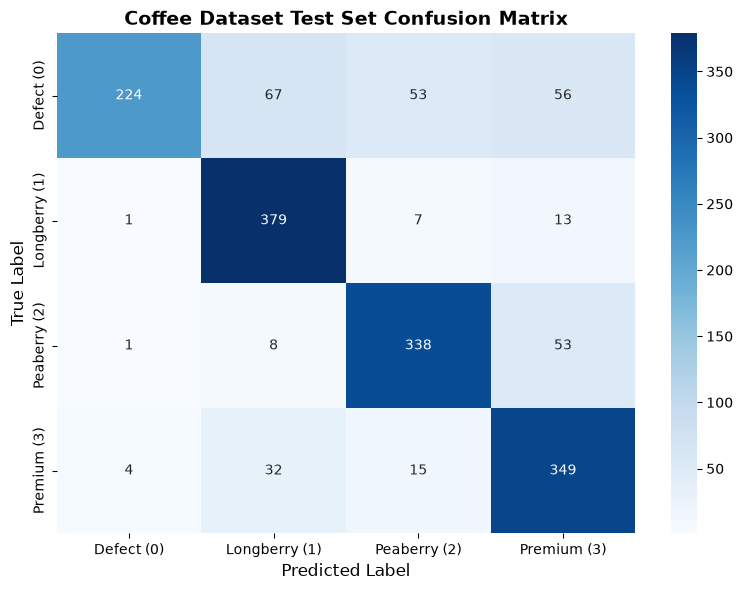

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluate overall loss and accuracy on the untouched test set
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nFinal Test Loss:     {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

# 2. Extract true labels across all batches
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# 3. Predict raw probability distributions for each sample (shape: [N, 4])
y_pred_probs = model.predict(test_ds, verbose=1)

# 4. Convert probabilities to discrete class indices (0, 1, 2, or 3)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Define class names matching dataset folder indices
class_names = ["Defect (0)", "Longberry (1)", "Peaberry (2)", "Premium (3)"]

# 6. Print detailed Classification Report (Precision, Recall, F1 per class)
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 7. Compute and Plot 4x4 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Coffee Dataset Test Set Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()